**Estudiante:** Ricardo Benalcazar
**Curso:** CDDEIA-ELMA-4-1

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

In [5]:
df=pd.read_csv('spam.csv', encoding='latin-1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df_nueva_data=df[['v1','v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df_nueva_data=df_nueva_data.rename(columns={'v1':'label','v2':'textos'})
df_nueva_data.head(10)

,label,textos
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [9]:
X = df_nueva_data['textos']
y=df_nueva_data['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=19)

In [11]:
vectorizador = CountVectorizer()

X_vectorizado = vectorizador.fit_transform(X_train)
X_vectorizado_test = vectorizador.transform(X_test)

Modelo Gaussian

In [12]:
modeloGaussian = GaussianNB()

In [13]:
modeloGaussian.fit(X_vectorizado.toarray(), y_train)

GaussianNB()

In [14]:
y_pred = modeloGaussian.predict(X_vectorizado_test.toarray())
print(y_pred)

['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [15]:
print("Accuracy de Gaussian: ",accuracy_score(y_test, y_pred))

Accuracy de Gaussian:  0.9061004784688995


In [16]:
score = f1_score(y_pred, y_test, pos_label='spam')
print('F1 Score: ',score)

F1 Score:  0.740495867768595


In [17]:
report = classification_report(y_test, y_pred, target_names=['spam','ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



Modelo Multinomial

In [18]:
modeloMultinomial = MultinomialNB()

In [19]:
modeloMultinomial.fit(X_vectorizado, y_train)

MultinomialNB()

In [20]:
y_pred_m = modeloMultinomial.predict(X_vectorizado_test)
print(y_pred_m)

['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [21]:
print("Accuracy de Multinomial: ",accuracy_score(y_test, y_pred_m))

Accuracy de Multinomial:  0.9856459330143541


In [26]:
precision = precision_score(y_test, y_pred_m, pos_label='spam')
recall = recall_score(y_test, y_pred_m, pos_label='spam')
f1 = f1_score(y_test, y_pred_m, pos_label='spam')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9704641350210971
Recall: 0.9311740890688259
F1 Score: 0.9504132231404959


In [27]:
report = classification_report(y_test, y_pred_m, target_names=['spam','ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.99      1.00      0.99      1425
         ham       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



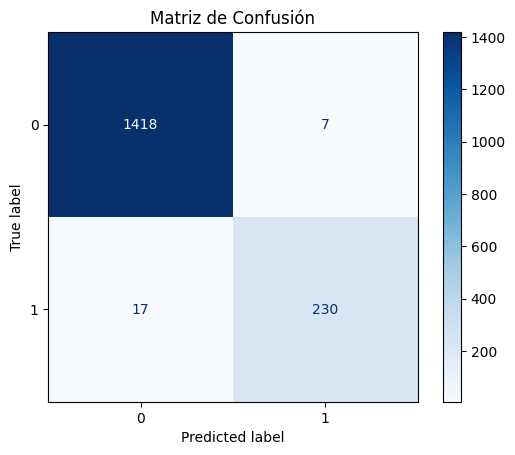

In [29]:
matriz_confusion = confusion_matrix(y_test, y_pred_m)

displayser = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
displayser.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()


El modelo tuvo una precision de 97%, el recall indica que tan bien identifica los casos positivos reales en este caso fue de un 93.1%, y tambien está el F1-Score que mide el balance entre precision y sensibilidad en este caso de un 95%. La matriz de confusión muestra que hubo pocos errores con solo 7 falsos positivos y 17 falsos negativos de las 1672 muestras, por lo cual se podria decir que el modelo es preciso, balanceado y confiable para este conjunto de datos.

In [39]:
y_proba = modeloMultinomial.predict_proba(X_vectorizado_test)[:,1]
print(y_proba)

[4.70748147e-12 9.99932537e-01 1.72196592e-05 ... 1.00000000e+00
 9.99995748e-01 2.30994979e-10]


In [41]:
r_s = roc_auc_score(y_test, y_proba)
print(r_s)

0.9891895731230911


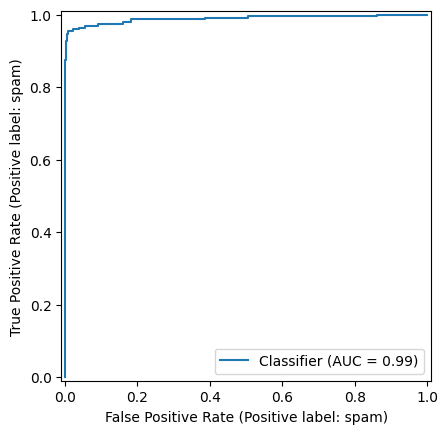

In [43]:
RocCurveDisplay.from_predictions(y_test, y_proba, pos_label='spam')
plt.show()